In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation
from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

def calculate_node_velocity(nodes, dt=1.0):
    """
    Calculate the velocity of each node over time.
    nodes: numpy array of shape (frames, num_nodes, 2) with (x, y) positions.
    dt: time difference between frames (default 1.0, set to actual frame interval if known).
    Returns:
        velocities: numpy array of shape (frames-1, num_nodes, 2) with (vx, vy) velocities.
        speeds: numpy array of shape (frames-1, num_nodes) with speed magnitudes.
    """
    velocities = (nodes[1:] - nodes[:-1]) / dt
    speeds = np.linalg.norm(velocities, axis=2)
    return velocities, speeds
    axs.plot(x_values, y_values, **kwargs)

**DATASET**

In [3]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset

def normalize(data, data_max, data_min):
    return (data - data_min) * 2 / (data_max - data_min) - 1

class PitchClassificationDataset(Dataset):
    def __init__(self, data_path, mode, data_len=-1):
        self.data_path = data_path
        self.mode = mode
        self.data_len = data_len
        
        # 1. Dynamically detect pitch classes from the training folders
        train_class_folders = sorted(glob.glob(os.path.join(data_path, 'train', '*')))
        self.classes = [os.path.basename(f) for f in train_class_folders if os.path.isdir(f)]
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        if mode == 'train':
            print(f"Detected Pitch Classes: {self.class_to_idx}")
            
        # 2. Get min/max values for normalization using the TRAIN set
        train_files = glob.glob(os.path.join(data_path, 'train', '*', '*.txt'))
        train_locs, train_vels = self._load_and_process_files(train_files)
        self.loc_max = max(loc.max() for loc in train_locs)
        self.loc_min = min(loc.min() for loc in train_locs)
        self.vel_max = max(vel.max() for vel in train_vels)
        self.vel_min = min(vel.min() for vel in train_vels)

        # 3. Load the requested split (train, val, or test) with their labels
        self.feat = []
        self.labels = []
        
        split_folders = glob.glob(os.path.join(data_path, mode, '*'))
        for folder in split_folders:
            cls_name = os.path.basename(folder)
            if cls_name not in self.class_to_idx:
                continue
                
            label_idx = self.class_to_idx[cls_name]
            files = glob.glob(os.path.join(folder, '*.txt'))
            
            locs, vels = self._load_and_process_files(files)
            
            for loc, vel in zip(locs, vels):
                loc_norm = normalize(loc, self.loc_max, self.loc_min)
                vel_norm = normalize(vel, self.vel_max, self.vel_min)
                combined = np.concatenate([loc_norm, vel_norm], axis=-1).astype(np.float32)
                
                self.feat.append(torch.from_numpy(combined))
                self.labels.append(label_idx)

    def _load_and_process_files(self, file_paths):
        all_locs, all_vels = [], []
        for file_path in file_paths:
            data = np.loadtxt(file_path)
            frames = data.shape[0]
            loc = np.zeros((frames, 17, 2))
            for i in range(17):
                loc[:, i, 0] = data[:, 5 + i*3]      
                loc[:, i, 1] = data[:, 5 + i*3 + 1]  
            vel = np.zeros_like(loc)
            vel[1:] = loc[1:] - loc[:-1]  
            all_locs.append(loc)
            all_vels.append(vel)
        return all_locs, all_vels

    def __getitem__(self, index):
        inputs = self.feat[index]
        label = self.labels[index]

        # Crop to fixed length if required
        if self.data_len > 0:
            size = len(inputs)
            if size > self.data_len:
                # Always take the end of the sequence where the pitch actually occurs
                start_ind = size - self.data_len
                inputs = inputs[start_ind:]

        return {'inputs': inputs, 'label': label}

    def __len__(self):
        return len(self.feat)

In [4]:
DATA_PATH = "D:/GitHub/BaseballPitch/data/finetuning_dataset/labels"
DATA_LEN = 176 # Adjust to your chosen sequence length

# Clean and simple, no pitch_type required
train_data = PitchClassificationDataset(DATA_PATH, 'train', data_len=DATA_LEN)
val_data = PitchClassificationDataset(DATA_PATH, 'val', data_len=DATA_LEN)
test_data = PitchClassificationDataset(DATA_PATH, 'test', data_len=DATA_LEN)

Detected Pitch Classes: {'CH - Changeup': 0, 'FF - Fastball': 1, 'SI - Sinker': 2, 'SL - Slider': 3, 'ST - Sweeper': 4}


**NRI - > STGCN MODEL**

In [5]:
import torch.nn.functional as F

class STGCNDecoderCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.linear_r = nn.Linear(input_size + hidden_size, hidden_size)
        self.linear_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.linear_n = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, hidden, A):
        combined = torch.cat([x, hidden], dim=-1)
        msg = torch.einsum('vw, bwc -> bvc', A, combined)
        r = torch.sigmoid(self.linear_r(msg))
        i = torch.sigmoid(self.linear_i(msg))
        combined_n = torch.cat([x, r * hidden], dim=-1)
        msg_n = torch.einsum('vw, bwc -> bvc', A, combined_n)
        n = torch.tanh(self.linear_n(msg_n))
        next_hidden = (1 - i) * n + i * hidden
        return next_hidden

In [6]:
import torch.nn as nn

class STGCNClassifier(nn.Module):
    def __init__(self, num_classes, num_vars=17, input_size=4, hidden_size=64):
        super().__init__()
        self.num_vars = num_vars
        self.hidden_size = hidden_size
        
        # 1. Build the Spatial Skeleton Graph Adjacency Matrix
        coco_connections = [
            (0, 1), (0, 2), (1, 3), (2, 4),
            (5, 6), (5, 11), (6, 12), (11, 12),
            (5, 7), (7, 9), (6, 8), (8, 10),
            (11, 13), (13, 15), (12, 14), (14, 16)
        ]
        
        A = np.zeros((num_vars, num_vars))
        for i, j in coco_connections:
            A[i, j] = 1
            A[j, i] = 1
        A += np.eye(num_vars)
        D = np.sum(A, axis=1)
        A_norm = A / D[:, None]
        self.register_buffer('A', torch.FloatTensor(A_norm))

        # 2. STGCN Temporal Cell
        self.cell = STGCNDecoderCell(input_size, hidden_size)
        
        # 3. Output Predictor (Classification Head)
        # We flatten the nodes at the end, so input is num_vars * hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * num_vars, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # Crucial for classification to prevent overfitting
            nn.Linear(128, num_classes)
        )

    def forward(self, inputs):
        """
        Inputs: [Batch, Time, Nodes, Features]
        Outputs: [Batch, Num_Classes] (Logits)
        """
        B, T, V, C = inputs.shape
        
        # Initialize hidden state
        hidden = torch.zeros(B, V, self.hidden_size, device=inputs.device)

        # Pass the sequence through the graph-recurrent cell
        for t in range(T):
            x_t = inputs[:, t]
            hidden = self.cell(x_t, hidden, self.A)

        # The final hidden state contains the spatio-temporal summary of the pitch.
        # Shape is currently [B, V, Hidden]. We flatten V and Hidden to map to classes.
        hidden_flat = hidden.view(B, V * self.hidden_size)
        
        logits = self.classifier(hidden_flat)
        return logits

# Initialize Model
num_classes = len(train_data.classes)
model = STGCNClassifier(num_classes=num_classes, hidden_size=64).cuda()
print(model)

STGCNClassifier(
  (cell): STGCNDecoderCell(
    (linear_r): Linear(in_features=68, out_features=64, bias=True)
    (linear_i): Linear(in_features=68, out_features=64, bias=True)
    (linear_n): Linear(in_features=68, out_features=64, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1088, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)


**TRAINING**

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- NEW: Calculate Class Weights ---
# Count the occurrences of each class in the training set
train_labels = train_data.labels
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
num_classes = len(train_data.classes)

# Calculate balanced weights: total_samples / (num_classes * count_for_class)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).cuda()

print(f"Class Counts: {class_counts}")
print(f"Computed Class Weights: {class_weights}")

# 1. Setup DataLoaders
batch_size = 32 # Adjust based on your GPU memory constraints
train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_data_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# 2. Setup Optimizer and Loss Function
# Pass the computed weights tensor to the loss function!
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# Add weight_decay to penalize overfitting
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. Training Loop Parameters
num_epochs = 50 # Adjust as needed
best_val_loss = float('inf')
best_val_epoch = 0

# --- NEW: Lists to track metrics for plotting ---
history_train_loss = []
history_val_loss = []
history_train_acc = []
history_val_acc = []

pbar = tqdm(range(1, num_epochs + 1), desc='Epochs')

for epoch in pbar:
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_data_loader:
        inputs = batch['inputs'].cuda(non_blocking=True)
        labels = batch['label'].cuda(non_blocking=True)

        # Forward pass
        logits = model(inputs)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        total_train_loss += loss.item()
        
        # Calculate Training Accuracy
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_loss = total_train_loss / len(train_data_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_data_loader:
            inputs = batch['inputs'].cuda(non_blocking=True)
            labels = batch['label'].cuda(non_blocking=True)

            logits = model(inputs)
            loss = criterion(logits, labels)
            
            total_val_loss += loss.item()
            
            # Calculate Validation Accuracy
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = total_val_loss / len(val_data_loader)
    val_acc = correct_val / total_val

    # Save the best model based on validation loss
    if val_loss < best_val_loss:
        best_val_epoch, best_val_loss = epoch, val_loss
        torch.save(model.state_dict(), 'best_pitch_classifier.pt')

    # --- NEW: Append metrics to history ---
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_train_acc.append(train_acc)
    history_val_acc.append(val_acc)

    # Update progress bar
    pbar.set_postfix({
        'Train Acc': f'{train_acc:.1%}',
        'Val Acc': f'{val_acc:.1%}',
        'Val Loss': f'{val_loss:.4f}'
    })

print(f"Training complete! Best Validation Loss: {best_val_loss:.4f} at Epoch {best_val_epoch}")

# Load the best model weights back in for testing
model.load_state_dict(torch.load('best_pitch_classifier.pt'))

Class Counts: [102 724 360 202 158]
Computed Class Weights: [3.03137255 0.42707182 0.85888889 1.53069307 1.95696203]


Epochs: 100%|██████████| 50/50 [11:19<00:00, 13.58s/it, Train Acc=23.4%, Val Acc=37.2%, Val Loss=1.5878]

Training complete! Best Validation Loss: 1.5801 at Epoch 2


<All keys matched successfully>

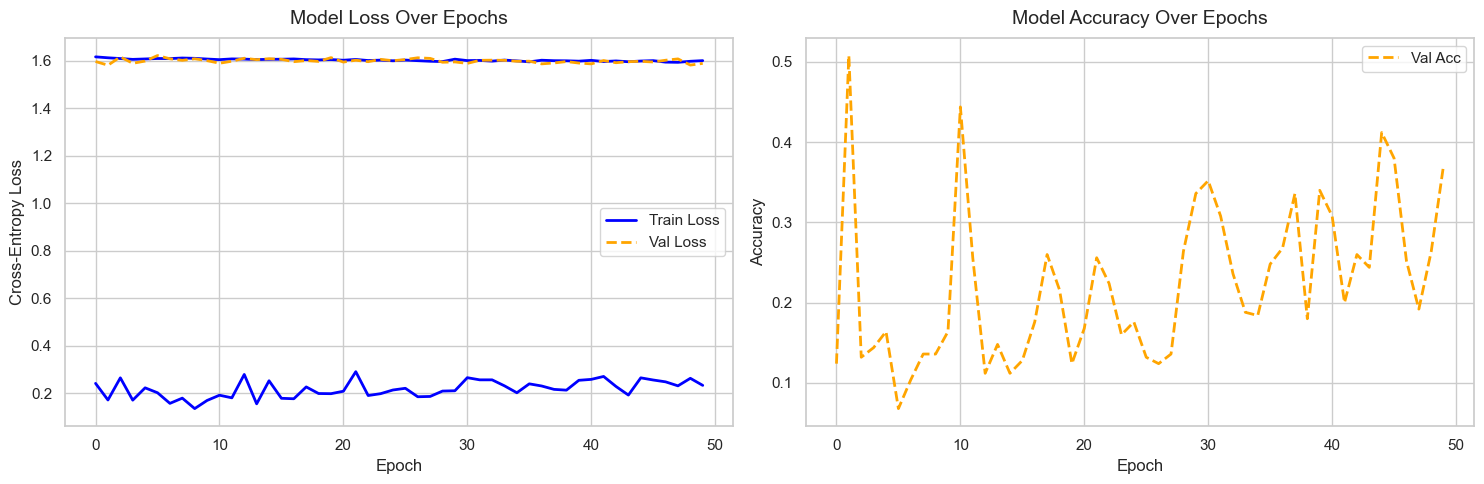

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: Loss ---
ax1.plot(history_train_loss, label='Train Loss', color='blue', linewidth=2)
ax1.plot(history_val_loss, label='Val Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Model Loss Over Epochs', fontsize=14, pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend(fontsize=11)

# --- Plot 2: Accuracy ---
ax1.plot(history_train_acc, label='Train Acc', color='blue', linewidth=2)
ax2.plot(history_val_acc, label='Val Acc', color='orange', linewidth=2, linestyle='--')
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

**TESTING**

Evaluating Pitch Classifier on Test Set...
Final Test Accuracy: 40.21%


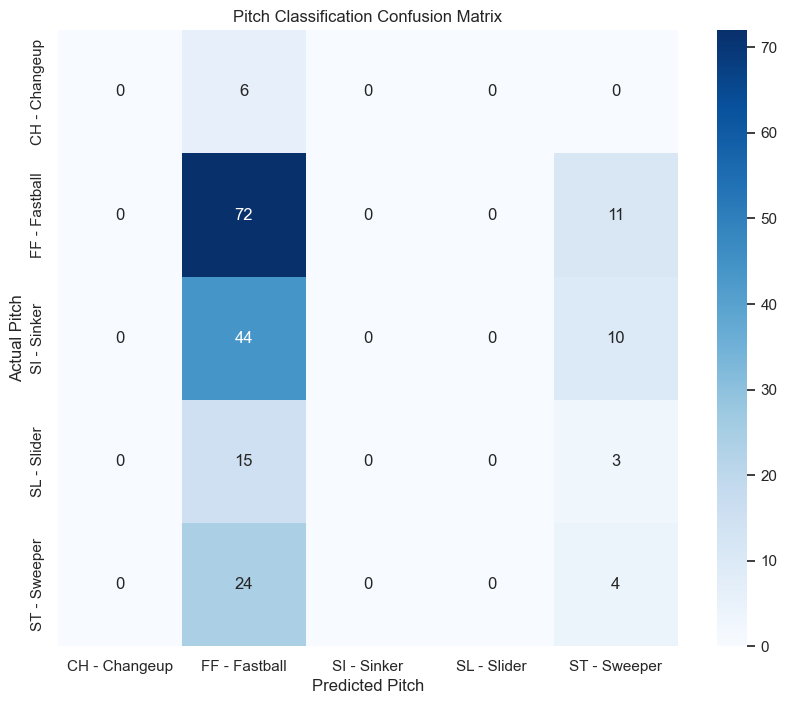

In [9]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Setup Test Loader
test_data_loader = DataLoader(test_data, batch_size=8, shuffle=False)

# 2. Evaluate Model
model.eval()
all_preds = []
all_labels = []
correct_test = 0
total_test = 0

print("Evaluating Pitch Classifier on Test Set...")
with torch.no_grad():
    for batch in test_data_loader:
        inputs = batch['inputs'].cuda(non_blocking=True)
        labels = batch['label'].cuda(non_blocking=True)
        
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

test_acc = correct_test / total_test
print(f"Final Test Accuracy: {test_acc:.2%}")

# 3. Plot Confusion Matrix
idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(len(idx_to_class))],
            yticklabels=[idx_to_class[i] for i in range(len(idx_to_class))])
plt.xlabel('Predicted Pitch')
plt.ylabel('Actual Pitch')
plt.title('Pitch Classification Confusion Matrix')
plt.show()

**INFERENCE**

In [10]:
import numpy as np
import torch

def predict_single_pitch(txt_file_path, model, train_dataset, data_len=176):
    """
    Loads a single pitch skeleton .txt file, normalizes it against the training 
    distribution, and returns the predicted pitch class.
    """
    model.eval()
    
    # 1. Load the raw data from the .txt file
    data = np.loadtxt(txt_file_path)
    frames = data.shape[0]
    
    # 2. Extract locations (x, y) based on your dataset format
    loc = np.zeros((frames, 17, 2))
    for i in range(17):
        loc[:, i, 0] = data[:, 5 + i*3]      # x
        loc[:, i, 1] = data[:, 5 + i*3 + 1]  # y
        
    # 3. Calculate velocities (vx, vy)
    vel = np.zeros_like(loc)
    vel[1:] = loc[1:] - loc[:-1] 
    
    # 4. Normalize using the training dataset's min/max values (CRITICAL)
    def normalize(d, d_max, d_min):
        return (d - d_min) * 2 / (d_max - d_min) - 1
        
    loc_norm = normalize(loc, train_dataset.loc_max, train_dataset.loc_min)
    vel_norm = normalize(vel, train_dataset.vel_max, train_dataset.vel_min)
    
    # 5. Combine and convert to tensor
    combined = np.concatenate([loc_norm, vel_norm], axis=-1).astype(np.float32)
    input_tensor = torch.from_numpy(combined)
    
    # 6. Crop to fixed length if required (matching your DATA_LEN)
    if data_len > 0:
        size = len(input_tensor)
        if size > data_len:
            # Take the first 'data_len' frames (matching validation logic)
            input_tensor = input_tensor[:data_len]
        elif size < data_len:
            print(f"Warning: File has {size} frames, expected {data_len}. Model might perform poorly.")
            
    # 7. Add batch dimension and move to GPU
    input_tensor = input_tensor.unsqueeze(0).cuda(non_blocking=True) # Shape: [1, Time, Nodes, Features]
    
    # 8. Run Inference
    with torch.no_grad():
        logits = model(input_tensor)
        
        # Apply Softmax to get percentages (optional, but good for confidence scores)
        probabilities = torch.nn.functional.softmax(logits, dim=1).squeeze()
        pred_idx = torch.argmax(probabilities).item()
        confidence = probabilities[pred_idx].item()
        
    # 9. Map index back to string class name
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    predicted_class = idx_to_class[pred_idx]
    
    return predicted_class, confidence

In [11]:
# Test it on a random file
sample_file = "D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt"

# Make sure you pass 'train_data' so it can access train_data.loc_max, etc.
predicted_pitch, confidence = predict_single_pitch(
    txt_file_path=sample_file, 
    model=model, 
    train_dataset=train_data, 
    data_len=DATA_LEN
)

print(f"Predicted Pitch: {predicted_pitch}")
print(f"Confidence: {confidence:.1%}")

Predicted Pitch: FF - Fastball
Confidence: 21.7%
